<>:48: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:48: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_497782/1296259043.py:48: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  ax.set_ylabel('99% Latency ($\mu$s)')  # Y轴标签 (只在最左侧图显示)


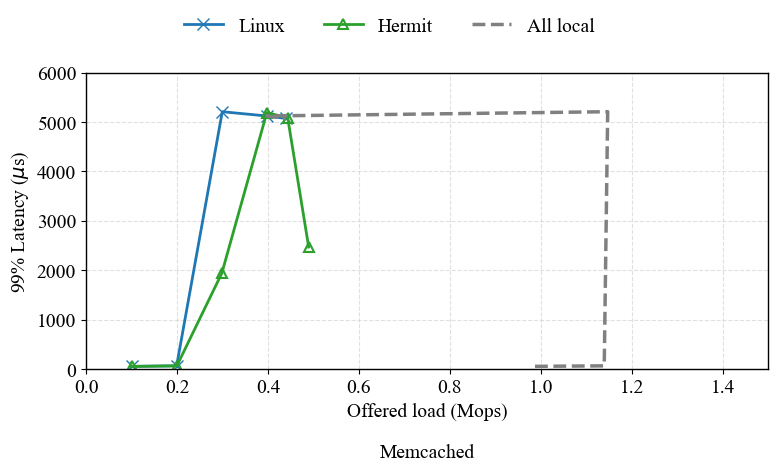

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ================= 1. 全局字体与样式设置 =================
# 顶会论文通常要求使用 Times New Roman 或类似衬线字体
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
plt.rcParams['font.size'] = 14
plt.rcParams['axes.linewidth'] = 1.0 # 坐标轴边框粗细

# ================= 2. 准备数据 (模拟你的测试结果) =================
# X轴: Offered load (Mops) -> 你的 QPS / 1000000
# Y轴: 99% Latency (μs)    -> 你的 p99_Latency_us

# 模拟数据：不同系统的吞吐量和延迟（你可以替换成你 CSV 里的真实数据）
load_linux = np.array([99989/1000000, 199099.5/1000000, 299520.8/1000000, 397439.4/1000000, 438908.1/1000000])
lat_linux = np.array([52.1, 61.8, 5206.7 , 5120.2, 5071.8])

load_hermit = np.array([99865.1/1000000, 199661.1/1000000,298590.7/1000000, 397551.6/1000000, 443385.7/1000000, 489600.4/1000000])
lat_hermit = np.array([49.5 , 62.1, 1939.4, 5189.4,5084.9,2467.2])

load_local = np.array([987437.7/1000000, 1139760.4/1000000, 1147337.7/1000000, 397439.4/1000000, 438908.1/1000000])
lat_local = np.array([52.1, 61.8, 5206.7 , 5120.2, 5071.8])

# ================= 3. 创建画布 (1行3列的排版) =================
# 这里以 1x3 的图为例，figsize (宽度, 高度)
fig, axes = plt.subplots(1, 1, figsize=(8, 4.5))

# 我们以第一个子图 axes[0] 为例画 Memcached
ax = axes

# ================= 4. 绘制折线图 (严格对齐论文颜色和 Marker) =================
# Linux (蓝色, 'x' 叉号)
ax.plot(load_linux, lat_linux, marker='x', color='#1f77b4', linestyle='-', 
        linewidth=2, markersize=8, label='Linux')

# Hermit (绿色, '^' 空心三角)
ax.plot(load_hermit, lat_hermit, marker='^', color='#2ca02c', linestyle='-', 
        linewidth=2, markersize=7, markerfacecolor='none', markeredgewidth=1.5, label='Hermit')

# All local (灰色, '--' 粗虚线, 无 marker)
ax.plot(load_local, lat_local, marker='', color='gray', linestyle='--', 
        linewidth=2.5, label='All local')

# ================= 5. 设置坐标轴、网格与标签 =================
ax.set_ylim(0, 6000)             # 严格限制 Y 轴范围到 500
ax.set_xlim(0, 2.5)             # 限制 X 轴范围
ax.set_ylabel('99% Latency ($\mu$s)')  # Y轴标签 (只在最左侧图显示)
ax.set_xlabel('Offered load (Mops)')   # X轴标签

# 添加背景虚线网格
ax.grid(True, linestyle='--', color='lightgray', alpha=0.7)

# 在子图下方添加副标题
ax.text(0.5, -0.25, 'Memcached', transform=ax.transAxes, 
        fontsize=14, ha='center', va='top')


# ================= 7. 提取图例并放到图表正上方 =================
# 获取 ax 的句柄，放在图表正上方居中，去除图例外框
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.1), 
           ncol=4, frameon=False, fontsize=14)

# 调整子图之间的间距，防止文字遮挡
plt.tight_layout()

# plt.show()